# Analyse du feu en foret boreale

Notebook minimal pour etudier la frequence d'occurrence des feux a partir de:
- FFBootCISap.csv (frequence des feux, FF)
- BBBootCISap.csv (biomasse brulee, BB)
- Lake_fire_frequency_24nov2023.csv (evenements par lac)

Sorties principales:
1. courbes temporelles FF/BB avec IC
2. RegFRI, RegBB et indice BB/FF (style article)
3. repartition des evenements de feu par lac et par classes d'age

## 1) Import des bibliotheques et style
Cette cellule charge les bibliotheques Python necessaires, applique un style de figure coherent et cree le dossier `figures_feu` pour l'export automatique des graphiques.

In [1]:
# Installation (si necessaire) :
# !pip install pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parametrage visuel commun a toutes les figures exportees
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10
})

# Options d'affichage des tableaux pandas dans le notebook
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

# Dossier de sortie pour centraliser les figures finales
figure_dir = Path('figures_feu')
figure_dir.mkdir(exist_ok=True)

## 2) Chargement des donnees feu
Cette cellule lit les fichiers FF, BB et le tableau des occurrences par lac. Elle verifie aussi que les fichiers indispensables sont bien disponibles.

In [2]:
# Chargement des donnees feu
ff_file = Path('FFBootCISap.csv')
bb_file = Path('BBBootCISap.csv')
fs_file = Path('FSBootCISap.csv')
lake_file = Path('Lake_fire_frequency_24nov2023.csv')

# FF, BB et FS sont indispensables pour reproduire la Figure 2 (RegBB, RegFRI, RegFS)
if not ff_file.exists() or not bb_file.exists() or not fs_file.exists():
    raise FileNotFoundError('FFBootCISap.csv, BBBootCISap.csv et/ou FSBootCISap.csv manquant(s).')

# Lecture des fichiers sources
ff_raw = pd.read_csv(ff_file)
bb_raw = pd.read_csv(bb_file)
fs_raw = pd.read_csv(fs_file)
lake_raw = pd.read_csv(lake_file, sep=';') if lake_file.exists() else None

# Controle rapide des volumes de donnees charges
print('FF shape:', ff_raw.shape)
print('BB shape:', bb_raw.shape)
print('FS shape:', fs_raw.shape)
print('Lake file present:', lake_raw is not None)

FF shape: (13063, 5)
BB shape: (13063, 5)
FS shape: (13063, 5)
Lake file present: True


## 3) Preparation des metriques
Cette cellule nettoie les colonnes numeriques, aligne FF, BB et FS sur l'age, puis calcule RegBB, RegFRI et RegFS avec leurs IC 90 % pour les 12 000 dernieres annees.

In [3]:
# Preparation des metriques feu (FF, BB, FS, RegFRI, RegBB, RegFS)
required_cols = ['Age', 'Mean', 'Infe', 'Supe']

def prepare_boot(df, label):
    out = df.copy()
    # Conversion explicite en numerique pour eviter les erreurs de type
    for c in required_cols:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.dropna(subset=required_cols).sort_values('Age')
    out['dataset'] = label
    # Deux echelles de temps utiles: kyr et cal. yr BP
    out['Age_kyr'] = out['Age'] / 1000.0
    out['Age_calBP'] = out['Age'].clip(lower=0)
    return out

ff_boot = prepare_boot(ff_raw, 'FFBootCISap')
bb_boot = prepare_boot(bb_raw, 'BBBootCISap')
fs_boot = prepare_boot(fs_raw, 'FSBootCISap')

# Jointure FF/BB/FS sur les memes ages pour comparer les signaux
comp_boot = (
    ff_boot[['Age', 'Age_kyr', 'Age_calBP', 'Mean', 'Infe', 'Supe']].rename(columns={
        'Mean': 'Mean_FF', 'Infe': 'Infe_FF', 'Supe': 'Supe_FF'
    })
    .merge(
        bb_boot[['Age', 'Age_kyr', 'Age_calBP', 'Mean', 'Infe', 'Supe']].rename(columns={
            'Mean': 'Mean_BB', 'Infe': 'Infe_BB', 'Supe': 'Supe_BB'
        }),
        on=['Age', 'Age_kyr', 'Age_calBP'], how='inner'
    )
    .merge(
        fs_boot[['Age', 'Age_kyr', 'Age_calBP', 'Mean', 'Infe', 'Supe']].rename(columns={
            'Mean': 'Mean_FS', 'Infe': 'Infe_FS', 'Supe': 'Supe_FS'
        }),
        on=['Age', 'Age_kyr', 'Age_calBP'], how='inner'
    )
    .sort_values('Age')
    .reset_index(drop=True)
)

article_df = comp_boot.copy()
# Proxies utilises dans l'article: frequence, biomasse brulee, retour du feu, taille/severite
article_df['RegFF'] = article_df['Mean_FF']
article_df['RegBB'] = article_df['Mean_BB']
article_df['RegFRI'] = 1.0 / article_df['RegFF']
article_df['RegFS'] = article_df['Mean_FS']

eps = 1e-12
# Encadrement d'incertitude (CI 90% issu des colonnes Infe/Supe)
article_df['RegBB_low'] = article_df['Infe_BB']
article_df['RegBB_high'] = article_df['Supe_BB']
article_df['RegFRI_low'] = 1.0 / (article_df['Supe_FF'] )
article_df['RegFRI_high'] = 1.0 / (article_df['Infe_FF'] )
article_df['RegFS_low'] = article_df['Infe_FS']
article_df['RegFS_high'] = article_df['Supe_FS']

# Figure 2: limiter explicitement aux 12 000 dernieres annees
article_df = article_df[(article_df['Age_calBP'] >= 0) & (article_df['Age_calBP'] <= 12000)].copy()
article_df = article_df.sort_values('Age_calBP').reset_index(drop=True)

# Lissage centre pour mettre en avant les tendances de fond
w = 101
article_df['RegBB_smooth'] = article_df['RegBB'].rolling(w, center=True, min_periods=1).mean()
article_df['RegFRI_smooth'] = article_df['RegFRI'].rolling(w, center=True, min_periods=1).mean()
article_df['RegFS_smooth'] = article_df['RegFS'].rolling(w, center=True, min_periods=1).mean()

# Alias de compatibilite pour les cellules historiques du notebook
article_df['FireSizeProxy'] = article_df['RegFS']
article_df['FireSize_smooth'] = article_df['RegFS_smooth']

display(article_df[['Age', 'RegFF', 'RegFRI', 'RegBB', 'RegFS']].head())

,Age,RegFF,RegFRI,RegBB,RegFS
0,-62,0.003970,251.913916,0.023641,0.688920
1,-28,0.003988,250.725160,0.030294,0.700156
2,-27,0.003989,250.687510,0.030791,0.700744
3,-26,0.003990,250.649872,0.031288,0.701331
4,-25,0.003990,250.612560,0.031346,0.701450


## 4) Figure 2 | Regional fire history
Cette cellule trace la Figure 2 au format article: a RegBB, b RegFRI et c RegFS, avec IC 90 % pour les 12 000 dernieres annees et la delimitation des sous-epoques (YD, early-, mid-, late-Holocene).

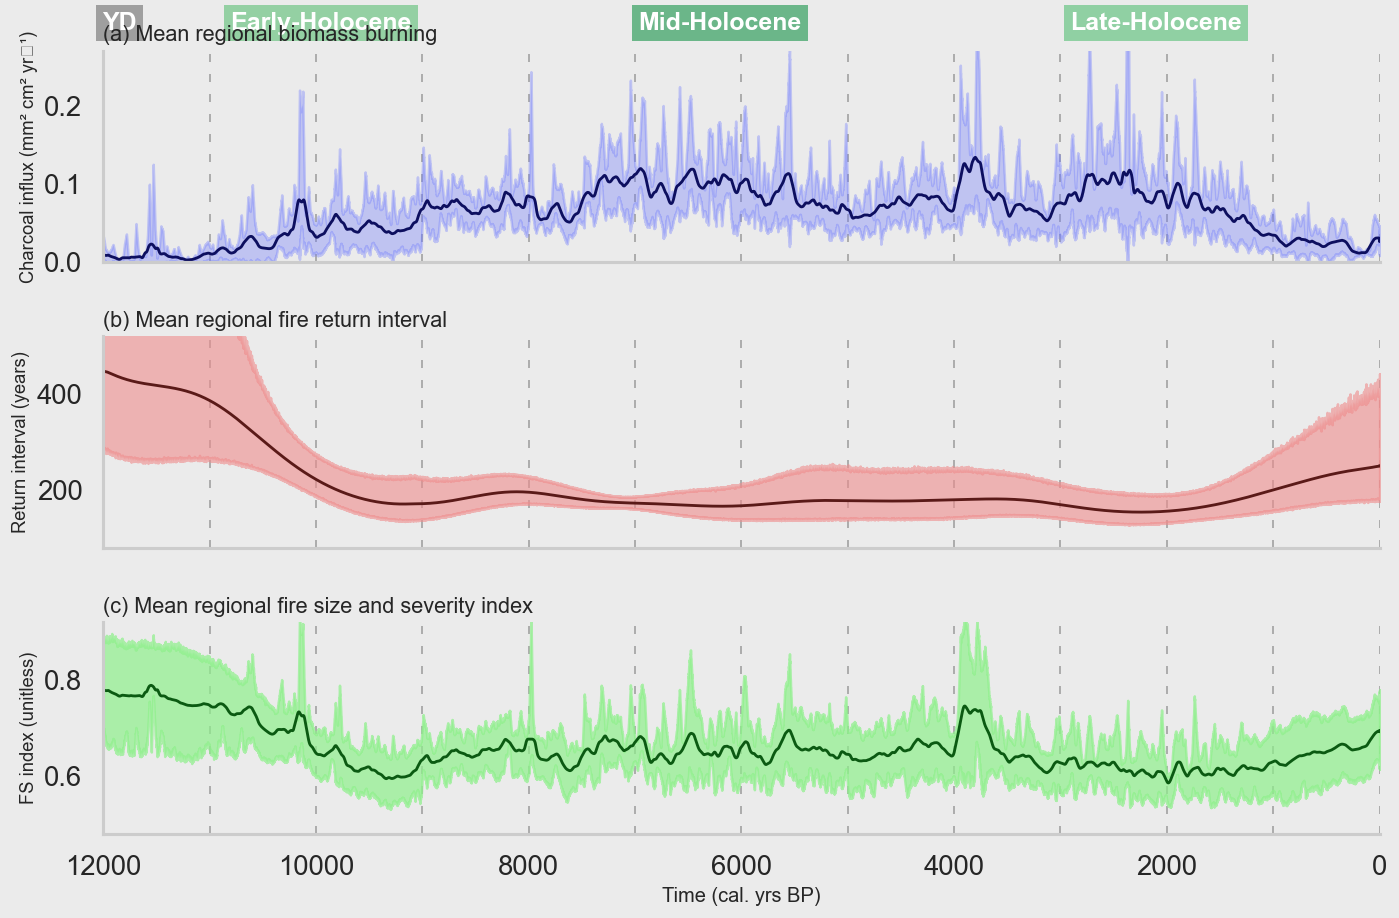

RegFRI                 RegBB               RegFS          
                          mean      median      mean    median      mean    median
Phase                                                                             
Late-Holocene       185.464555  179.187465  0.066024  0.066224  0.637442  0.631455
Mid-Holocene        176.694282  177.117311  0.084094  0.079940  0.651941  0.649405
Early-Holocene      263.621870  215.985980  0.039252  0.038318  0.681083  0.663440
Younger Dryas (YD)  436.202555  435.245862  0.005693  0.005434  0.770099  0.770159

In [4]:
# Figure 2 | Regional fire history: style rapproche de l'article
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.patch.set_facecolor('#ebebeb')

# Sous-epoques sur les 12 000 dernieres annees (cal. yr BP)
# Format: (start, end, label, color_bg, color_text)
epoch_windows = [
    (11700, 12000, 'YD', '#9b9b9b', '#ffffff'),
    (8200, 11700, 'Early-Holocene', '#8fcf9f', '#ffffff'),
    (4200, 8200, 'Mid-Holocene', '#64b484', '#ffffff'),
    (0, 4200, 'Late-Holocene', '#8bcf9f', '#ffffff')
]

# Panneau a: biomasse brulee regionale (RegBB)
axes[0].plot(article_df['Age_calBP'], article_df['RegBB_smooth'], color='#0d0f5f', lw=1.7)
axes[0].fill_between(article_df['Age_calBP'], article_df['RegBB_low'], article_df['RegBB_high'], color='#6d79ff', alpha=0.35)
axes[0].set_title('(a) Mean regional biomass burning', loc='left', fontsize=13, fontweight='normal')
axes[0].set_ylabel('Charcoal influx (mm² cm² yr⁻¹)', fontsize=11)
axes[0].set_ylim(0, 0.27)

# Panneau b: intervalle de retour du feu (RegFRI)
axes[1].plot(article_df['Age_calBP'], article_df['RegFRI_smooth'], color='#5a1a18', lw=1.7)
axes[1].fill_between(article_df['Age_calBP'], article_df['RegFRI_low'], article_df['RegFRI_high'], color='#ef8d8d', alpha=0.6)
axes[1].set_title('(b) Mean regional fire return interval', loc='left', fontsize=13, fontweight='normal')
axes[1].set_ylabel('Return interval (years)', fontsize=11)
axes[1].set_ylim(80, 520)

# Panneau c: indice regional de taille/severite (RegFS)
axes[2].plot(article_df['Age_calBP'], article_df['RegFS_smooth'], color='#0b5a12', lw=1.7)
axes[2].fill_between(article_df['Age_calBP'], article_df['RegFS_low'], article_df['RegFS_high'], color='#8ff08c', alpha=0.7)
axes[2].set_title('(c) Mean regional fire size and severity index', loc='left', fontsize=13, fontweight='normal')
axes[2].set_ylabel('FS index (unitless)', fontsize=11)
axes[2].set_ylim(0.48, 0.92)
axes[2].set_xlabel('Time (cal. yrs BP)', fontsize=12)

# Style des axes (fond gris clair + lignes verticales pointillees)
for ax in axes:
    ax.set_facecolor('#ebebeb')
    ax.set_xlim(0, 12000)
    for x in np.arange(0, 12001, 1000):
        ax.axvline(x=x, color='0.68', linestyle=(0, (4, 6)), linewidth=1.2, zorder=0)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_xaxis()

# Bandeau des sous-epoques en haut du premier panneau
for x0, x1, label, color_bg, color_text in epoch_windows:
    x_center = (x0 + x1) / 2
    axes[0].text(
        x_center,
        1.13,
        label,
        transform=axes[0].get_xaxis_transform(),
        ha='center',
        va='center',
        fontsize=15,
        fontweight='bold',
        color=color_text,
        bbox=dict(boxstyle='square,pad=0.25', facecolor=color_bg, edgecolor='none', alpha=0.95)
    )

plt.tight_layout()
fig.savefig(figure_dir / 'fig_02_regional_fire_history.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close(fig)

# Resume par phase
phase_df = article_df.copy()
phase_df['Phase'] = pd.cut(
    phase_df['Age_calBP'],
    bins=[0, 4200, 8200, 11700, 12000.0001],
    labels=['Late-Holocene', 'Mid-Holocene', 'Early-Holocene', 'Younger Dryas (YD)'],
    right=False
)
phase_summary = phase_df.groupby('Phase', observed=True)[['RegFRI', 'RegBB', 'RegFS']].agg(['mean', 'median'])
display(phase_summary)

### Interpretation specifique de la Figure 2 (ce que montre le graphe)

Lecture directe des trois panneaux:

- (a) RegBB (biomasse brulee):
  le signal est tres faible vers 12 000-11 000 cal BP (~0.00-0.02), puis augmente jusqu'a un plateau holocene moyen/recents (~0.06-0.12). On observe des pics nets autour de 7 000-6 000 et ~4 000 cal BP, puis une baisse vers le present (proche de 0.02-0.04 dans les derniers millenaires).
- (b) RegFRI (intervalle de retour):
  tres eleve au debut (~430-450 ans vers 12 ka), chute rapide jusqu'a ~170-200 ans entre 9 ka et 6 ka, reste relativement bas au centre de l'Holocene, puis remonte apres ~2 ka pour atteindre ~250 ans vers le present.
- (c) RegFS (taille/severite):
  niveau eleve au debut (~0.77-0.79), minimum relatif vers 9.5-9 ka (~0.60), regime plutot stable ensuite (~0.62-0.68), pic marque autour de 4 ka (~0.74-0.76), puis creux vers 2 ka (~0.60-0.62) et remontée legere en fin de serie (~0.67-0.69).

Interpretation combinee:
- Debut de serie (12-10 ka): feux plus rares (FRI haut), mais severite/ampleur relativement forte (FS haut).
- Holocene moyen (8-4 ka): feux plus frequents (FRI bas) avec biomasse brulee soutenue (RegBB moyen a eleve).
- Holocene recent (<2 ka): ralentissement relatif du regime (RegBB en baisse, FRI en hausse), avec FS qui repart legerement en fin de serie.

Note: les bandes colorees montrent une incertitude plus large aux extremites temporelles (debut et fin), donc la confiance est meilleure dans la partie centrale de la chronologie.

## 5) Zoom par periodes de 2000 ans
Cette section decoupe la chronologie en fenetres de 2000 ans. Elle produit un tableau de synthese par periode et une figure de zoom pour chaque tranche temporelle afin de voir les variations fines de RegBB, RegFRI et RegFS.

RegFF                                    RegFRI                                         RegBB                                   RegFS  \
                      mean    median       min       max        mean      median         min         max      mean    median       min       max      mean   
Periode_2000_ans                                                                                                                                             
[0, 2000)         0.005060  0.004952  0.003970  0.006412  202.498268  201.944203  155.951232  251.913916  0.042810  0.033801  0.008612  0.130656  0.633141   
[2000, 4000)      0.005958  0.005894  0.005509  0.006491  168.553650  169.672991  154.050425  181.518478  0.089080  0.081732  0.043023  0.234395  0.639990   
[4000, 6000)      0.005678  0.005636  0.005567  0.005978  176.188259  177.416180  167.293040  179.614056  0.077150  0.075549  0.045657  0.149915  0.652675   
[6000, 8000)      0.005712  0.005789  0.005114  0.006013  175.473015  172.754537  166.316736  195.548610  0.091087  0.091787  0.037325  0.160897  0.651201   
[8000, 10000)     0.005420  0.005456  0.004503  0.005854  185.295878  183.285248  170.822289  222.071115  0.058083  0.059252  0.028369  0.115551  0.633816   
[10000, 12000)    0.002888  0.002587  0.002219  0.004500  361.088378  386.546640  222.198768  450.654260  0.018887  0.012530  0.000913  0.120499  0.739220   

                                                
                    median       min       max  
Periode_2000_ans                                
[0, 2000)         0.631407  0.569100  0.701450  
[2000, 4000)      0.627986  0.576079  0.794172  
[4000, 6000)      0.651303  0.613150  0.728361  
[6000, 8000)      0.646081  0.596287  0.779924  
[8000, 10000)     0.638960  0.583342  0.698066  
[10000, 12000)    0.748219  0.643473  0.827715

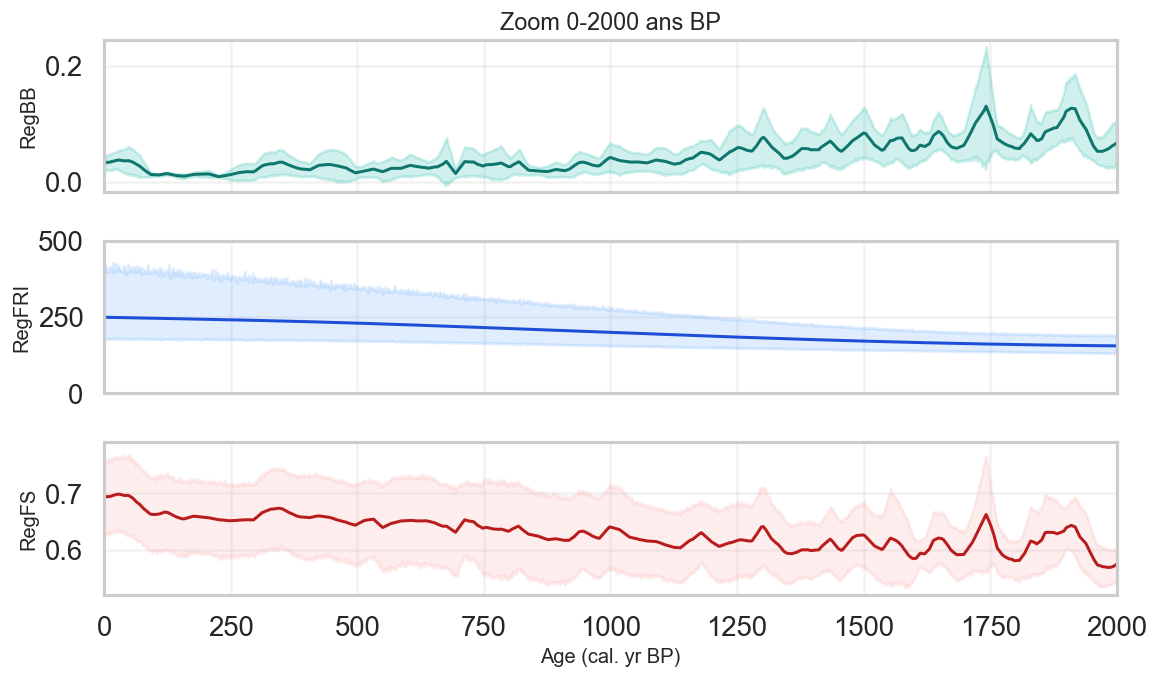

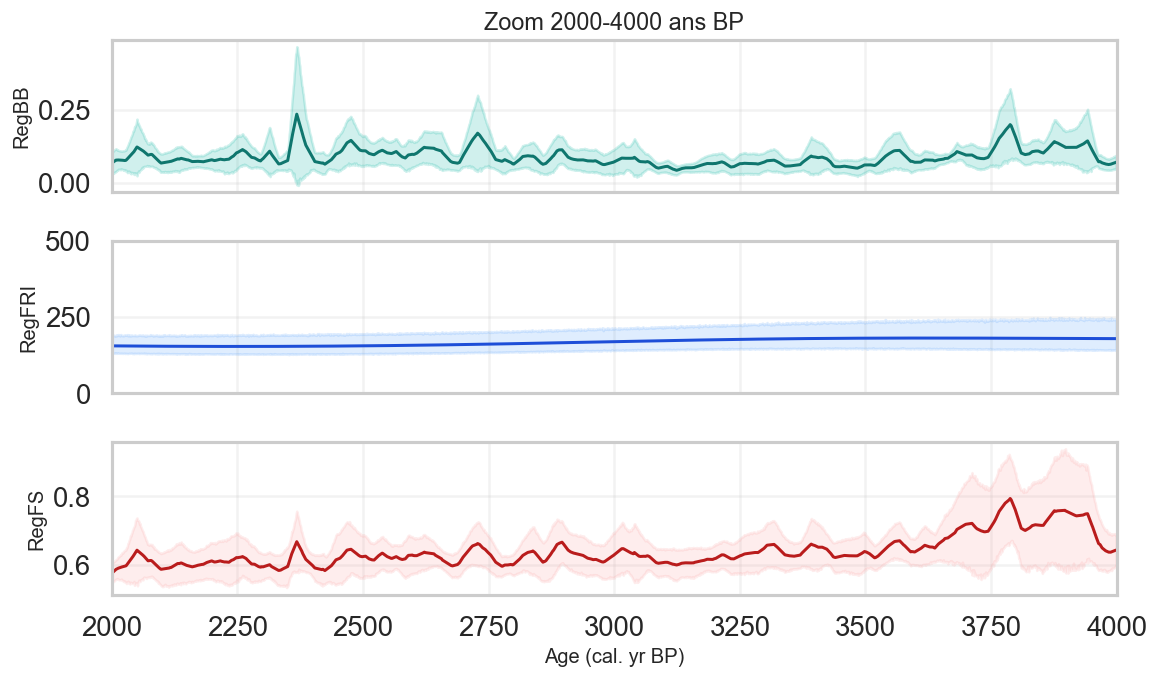

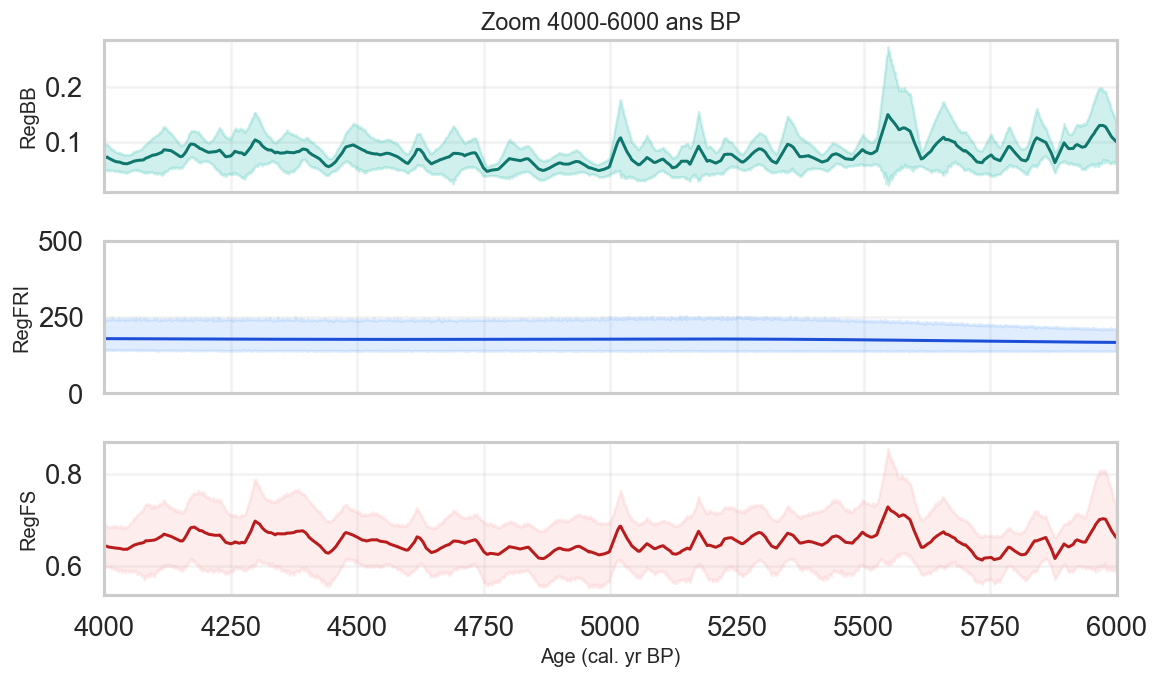

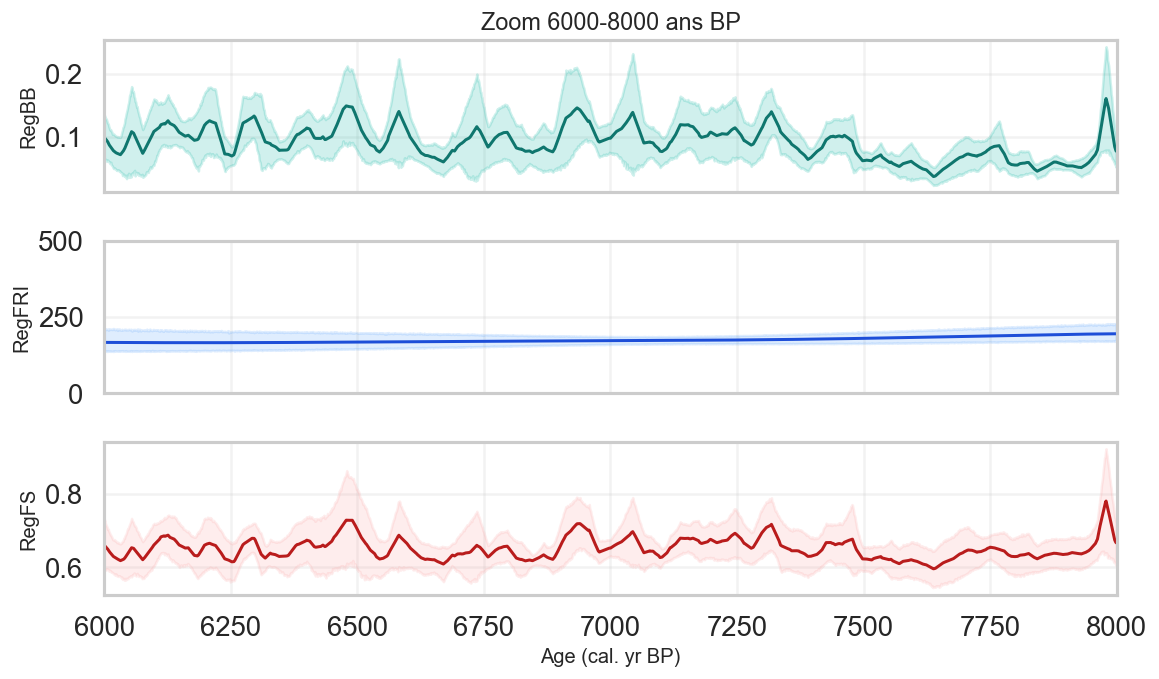

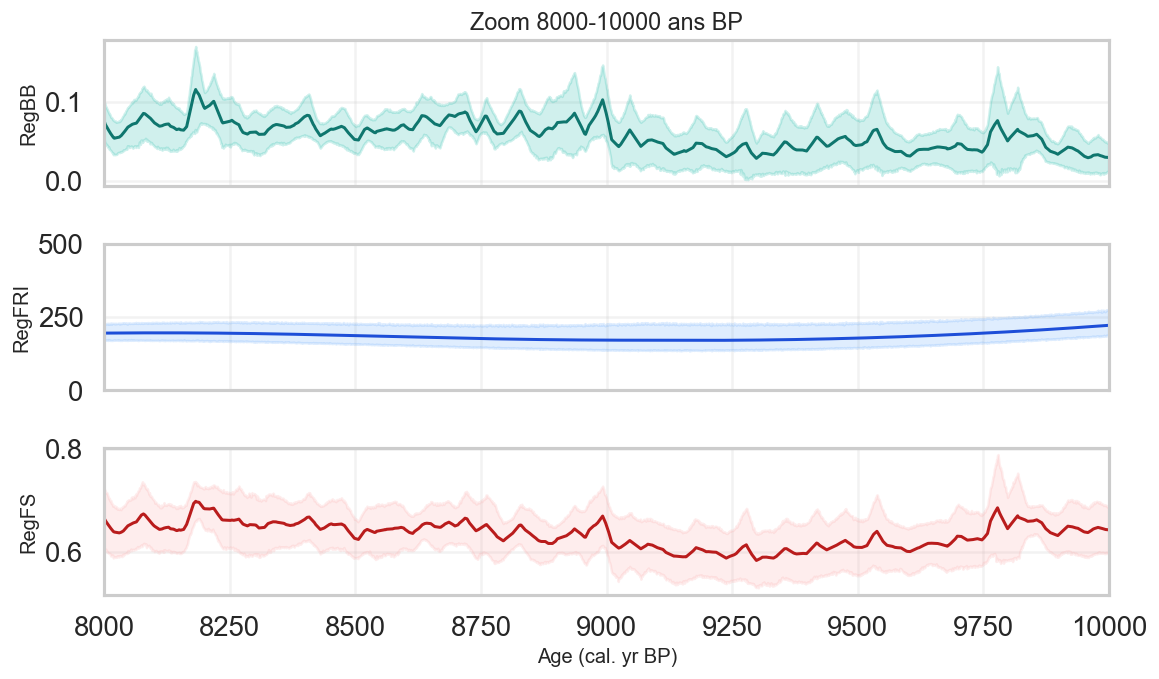

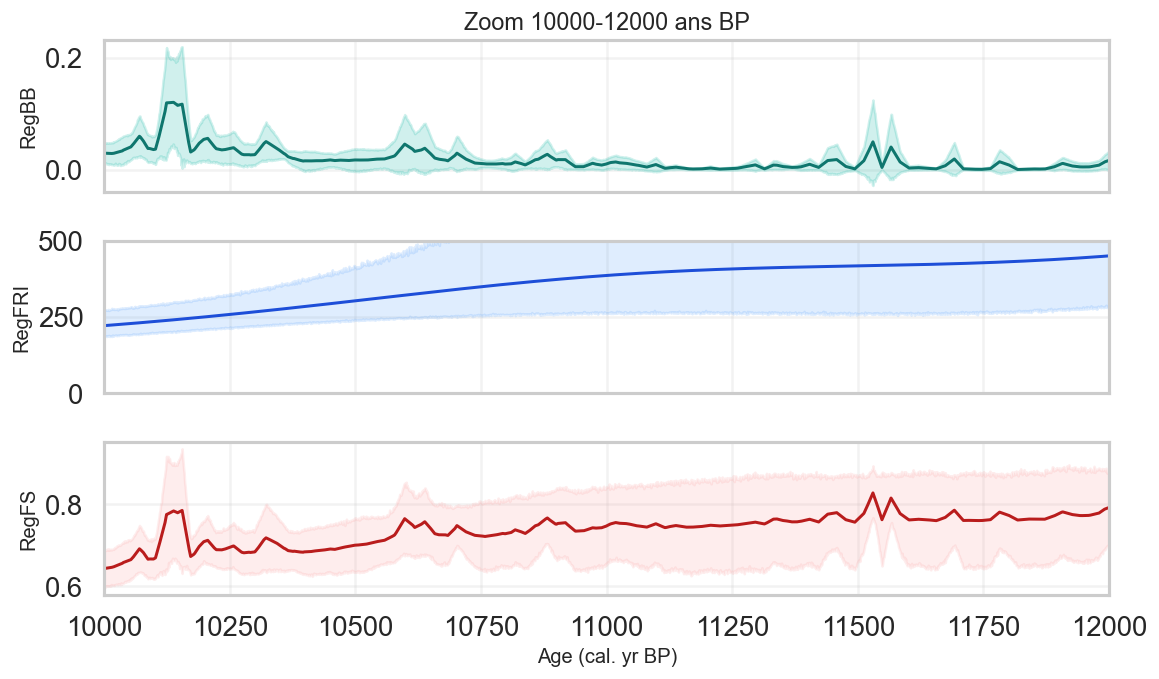

In [5]:
# Zoom par periodes de 2000 ans
step_years = 2000
max_age = int(np.ceil(article_df['Age_calBP'].max()))
period_edges = np.arange(0, max_age + step_years, step_years)
if period_edges[-1] < max_age:
    period_edges = np.append(period_edges, max_age + 1)

zoom_df = article_df.copy()
zoom_df['Periode_2000_ans'] = pd.cut(
    zoom_df['Age_calBP'],
    bins=period_edges,
    right=False,
    include_lowest=True
 )

# Tableau de synthese par tranche de 2000 ans
summary_2000 = zoom_df.groupby('Periode_2000_ans', observed=True)[
    ['RegFF', 'RegFRI', 'RegBB', 'RegFS']
].agg(['mean', 'median', 'min', 'max'])
display(summary_2000)

# Une figure de zoom par periode pour lire finement les variations
period_labels = zoom_df['Periode_2000_ans'].dropna().unique()
for i, p in enumerate(period_labels, start=1):
    z = zoom_df[zoom_df['Periode_2000_ans'] == p].copy()
    if z.empty:
        continue

    x0, x1 = float(p.left), float(p.right)
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(z['Age_calBP'], z['RegBB'], color='#0f766e', lw=1.8)
    axes[0].fill_between(z['Age_calBP'], z['RegBB_low'], z['RegBB_high'], color='#14b8a6', alpha=0.2)
    axes[0].set_ylabel('RegBB')
    axes[0].set_title(f'Zoom {int(x0)}-{int(x1)} ans BP')

    axes[1].plot(z['Age_calBP'], z['RegFRI'], color='#1d4ed8', lw=1.8)
    axes[1].fill_between(z['Age_calBP'], z['RegFRI_low'], z['RegFRI_high'], color='#60a5fa', alpha=0.2)
    axes[1].set_ylabel('RegFRI')
    axes[1].set_ylim(0, 500)

    axes[2].plot(z['Age_calBP'], z['RegFS'], color='#b91c1c', lw=1.8)
    axes[2].fill_between(z['Age_calBP'], z['RegFS_low'], z['RegFS_high'], color='#fca5a5', alpha=0.2)
    axes[2].set_ylabel('RegFS')
    axes[2].set_xlabel('Age (cal. yr BP)')

    for ax in axes:
        ax.set_xlim(x0, x1)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    fig.savefig(figure_dir / f'fig_05_zoom_{int(x0)}_{int(x1)}_bp.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

### Interpretation specifique des patterns 2000 ans

Ce que montrent les figures et tableaux de zoom:

- 0-2000 cal BP: RegBB faible a modere et RegFRI en hausse progressive -> regime de feu globalement moins actif qu'au coeur de l'Holocene.
- 2000-4000 cal BP: variabilite elevee avec un episode fort autour de ~4 ka visible sur RegBB et RegFS.
- 4000-8000 cal BP: c'est la zone la plus active de la serie, avec RegBB souvent eleve et RegFRI bas a intermediaire (feux plus rapproches).
- 8000-10000 cal BP: transition vers des niveaux plus faibles de RegBB et un FRI qui commence a remonter.
- 10000-12000 cal BP: contraste net avec FRI tres eleve et RegBB bas.

Message cle des zooms:
la dynamique n'est pas lineaire. On a un optimum d'activite feu au milieu de l'Holocene, encadre par deux phases moins actives (debut tres ancien et periode recente).

## 5) Occurrences de feu par lac
Cette cellule visualise la frequence des evenements par lac, la distribution des ages et une heatmap par classes d'age. Les figures sont egalement exportees en PNG.

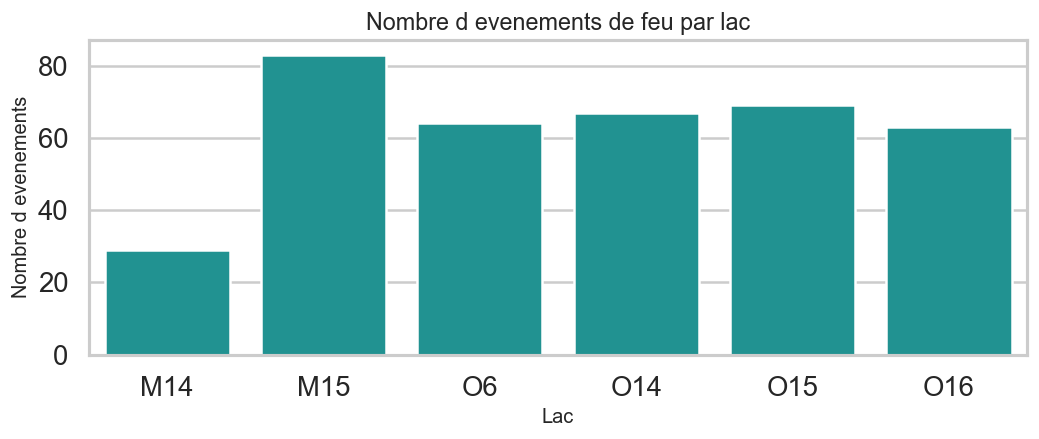

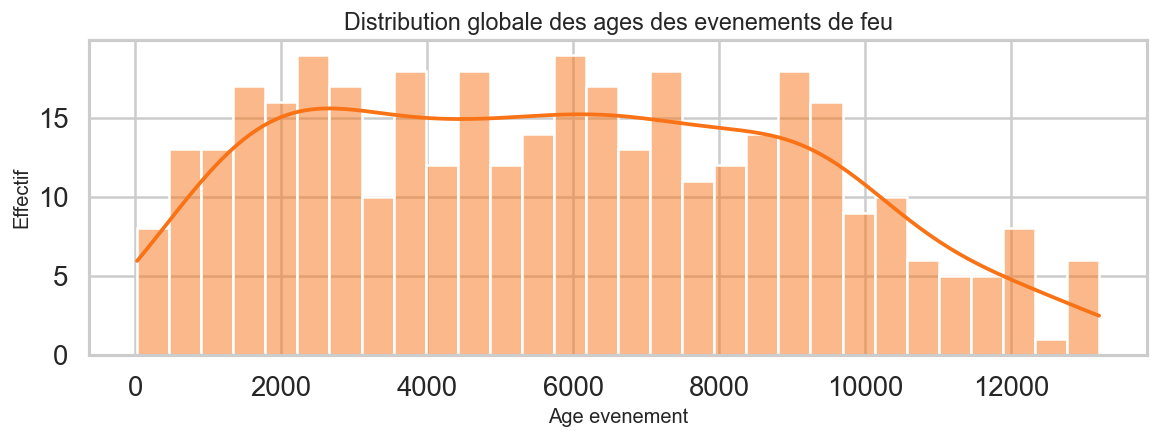

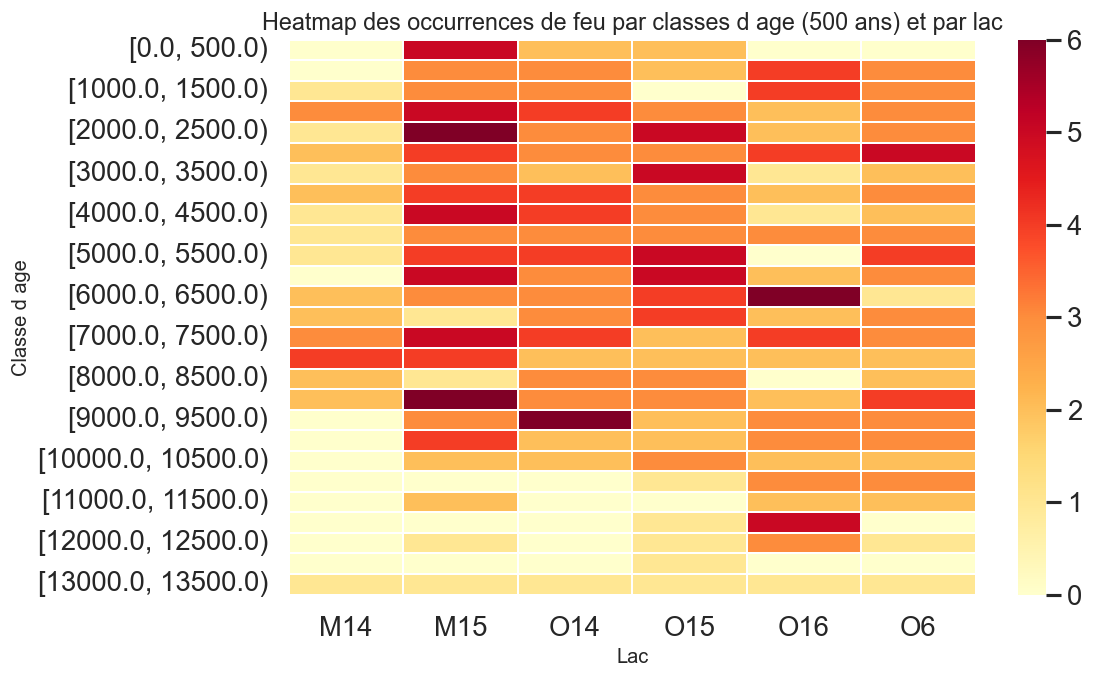


=== ANALYSE DETAILLEE PAR PERIODE DE 1000 ANS ===

Nombre d'evenements de feu par lac et par periode de 1000 ans :


Lac,M14,M15,O14,O15,O16,O6
Periode_1000ans,,,,,,
"[0, 1000)",0,8,5,4,4,3
"[1000, 2000)",4,8,7,3,6,6
"[2000, 3000)",3,10,6,8,6,8
"[3000, 4000)",3,7,6,8,3,5
"[4000, 5000)",2,8,7,6,4,5
"[5000, 6000)",1,9,7,10,2,7
"[6000, 7000)",4,4,6,8,8,4
"[7000, 8000)",7,9,6,4,6,5
"[8000, 9000)",4,7,6,6,2,6


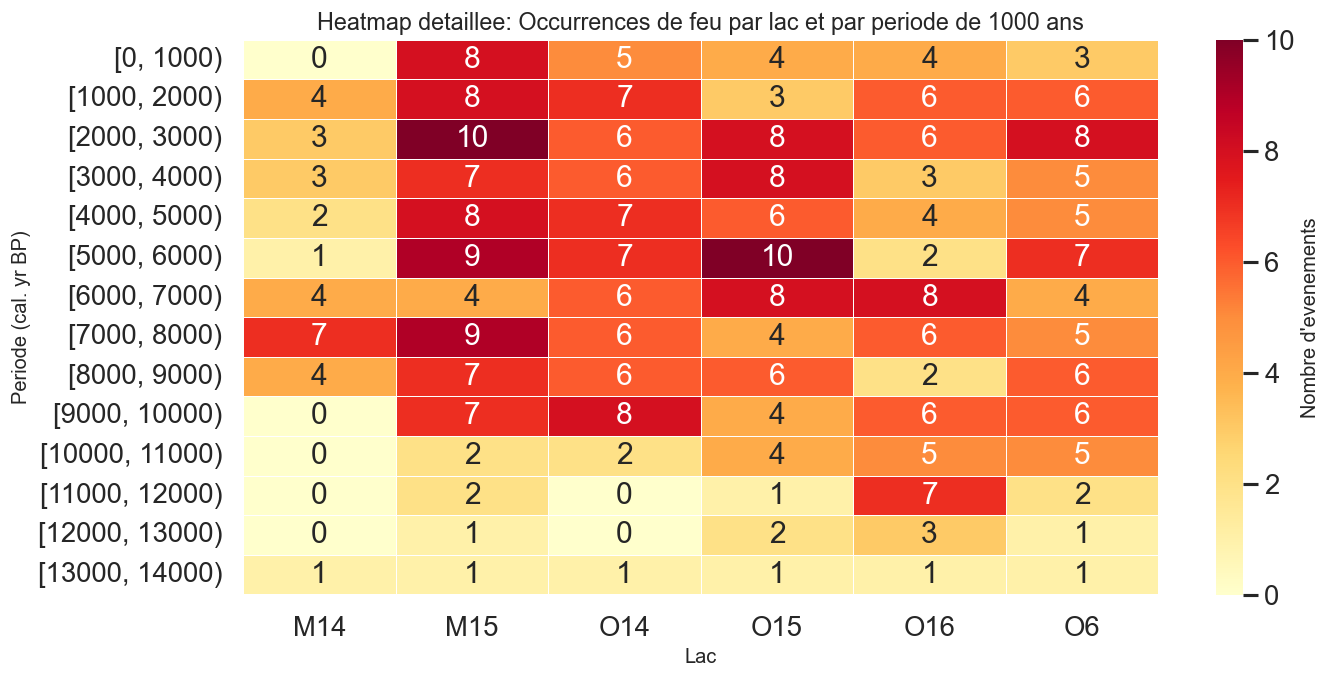

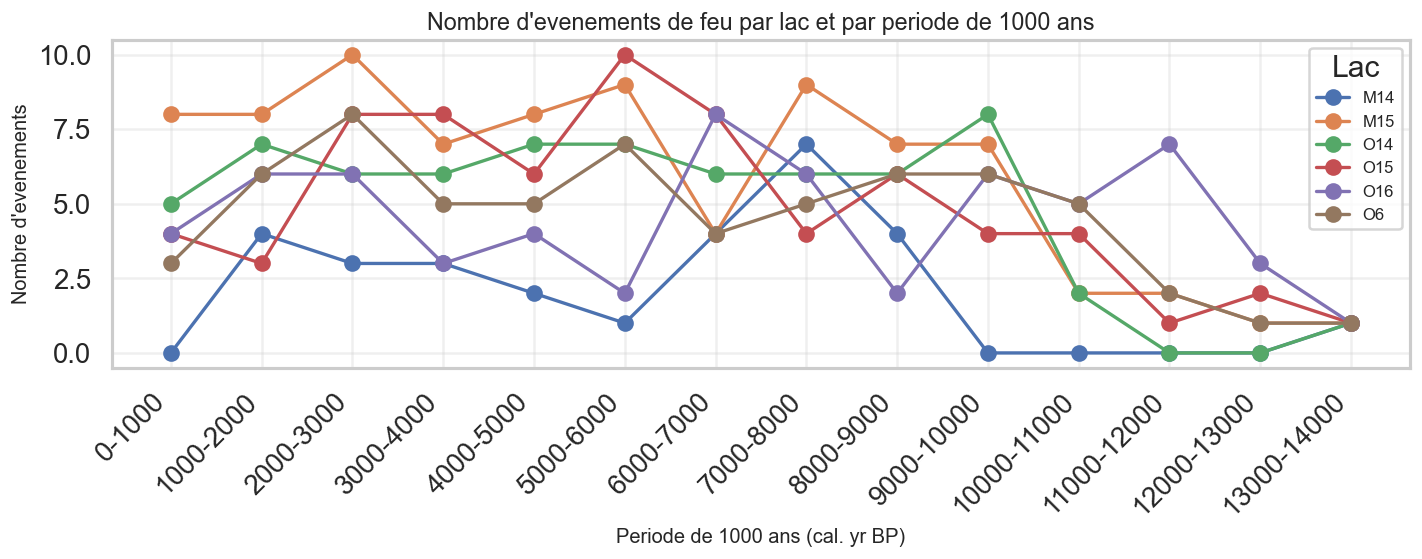


=== STATISTIQUES RESUMEES PAR LAC ===



,Nombre_total,Age_moyen,Age_median,Age_min,Age_max
Lac,,,,,
M14,29,5736.068966,6450.0,1307.0,13200.0
M15,83,5293.277108,5014.0,28.0,13200.0
O14,67,5405.432836,5306.0,70.0,13200.0
O15,69,5781.594203,5582.0,57.0,13200.0
O16,63,6709.079365,6796.0,532.0,13200.0
O6,64,5996.156250,5718.0,638.0,13200.0


In [6]:
# Occurrences de feu par lac
if lake_raw is None:
    print('Lake_fire_frequency_24nov2023.csv non trouve.')
else:
    lake = lake_raw.apply(pd.to_numeric, errors='coerce')
    # Convention du fichier: valeur negative = absence d'evenement
    lake = lake.where(lake >= 0)
    lake_long = lake.melt(var_name='Lac', value_name='Age_event').dropna()

    # Figure 1: comparaison du nombre total d'evenements par lac
    fig1 = plt.figure(figsize=(9, 4))
    sns.countplot(data=lake_long, x='Lac', color='#0ea5a4')
    plt.title('Nombre d evenements de feu par lac')
    plt.xlabel('Lac')
    plt.ylabel('Nombre d evenements')
    plt.tight_layout()
    fig1.savefig(figure_dir / 'fig_02_evenements_par_lac.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig1)

    # Figure 2: distribution globale des ages d'evenements
    fig2 = plt.figure(figsize=(10, 4))
    sns.histplot(data=lake_long, x='Age_event', bins=30, kde=True, color='#f97316')
    plt.title('Distribution globale des ages des evenements de feu')
    plt.xlabel('Age evenement')
    plt.ylabel('Effectif')
    plt.tight_layout()
    fig2.savefig(figure_dir / 'fig_03_distribution_ages_evenements.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig2)

    # Figure 3: intensite des occurrences par classes d'age et par lac (resolution 500 ans)
    bins = np.arange(0, np.nanmax(lake_long['Age_event']) + 500, 500)
    lake_long['Age_bin'] = pd.cut(lake_long['Age_event'], bins=bins, right=False)
    heat = lake_long.groupby(['Age_bin', 'Lac'])['Age_event'].count().unstack(fill_value=0)

    fig3 = plt.figure(figsize=(10, 6))
    sns.heatmap(heat, cmap='YlOrRd', linewidths=0.2)
    plt.title('Heatmap des occurrences de feu par classes d age (500 ans) et par lac')
    plt.xlabel('Lac')
    plt.ylabel('Classe d age')
    plt.tight_layout()
    fig3.savefig(figure_dir / 'fig_04_heatmap_occurrences_par_lac_500ans.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig3)

    # Figure 4: Analyse detaillee par periode de 1000 ans
    print("\n=== ANALYSE DETAILLEE PAR PERIODE DE 1000 ANS ===\n")

    # Definir les periodes de 1000 ans
    max_age_lake = int(np.ceil(lake_long['Age_event'].max()))
    period_edges_1000 = np.arange(0, max_age_lake + 1000, 1000)
    lake_long['Periode_1000ans'] = pd.cut(
        lake_long['Age_event'],
        bins=period_edges_1000,
        right=False,
        include_lowest=True
    )

    # Tableau de synthese: nombre d'evenements par lac et par periode de 1000 ans
    synthese_1000 = lake_long.groupby(['Periode_1000ans', 'Lac']).size().unstack(fill_value=0)
    print("Nombre d'evenements de feu par lac et par periode de 1000 ans :")
    display(synthese_1000)

    # Heatmap par periode de 1000 ans
    fig4 = plt.figure(figsize=(12, 6))
    sns.heatmap(synthese_1000, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Nombre d\'evenements'})
    plt.title('Heatmap detaillee: Occurrences de feu par lac et par periode de 1000 ans')
    plt.xlabel('Lac')
    plt.ylabel('Periode (cal. yr BP)')
    plt.tight_layout()
    fig4.savefig(figure_dir / 'fig_05_heatmap_occurrences_par_lac_1000ans.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig4)

    # Figure 5: Courbes temporelles de frequence d'evenements par lac (cumul sur periodes de 1000 ans)
    fig5, ax = plt.subplots(figsize=(12, 5))
    for lac in synthese_1000.columns:
        ax.plot(range(len(synthese_1000)), synthese_1000[lac].values, marker='o', label=lac, linewidth=2)
    ax.set_xlabel('Periode de 1000 ans (cal. yr BP)')
    ax.set_ylabel('Nombre d\'evenements')
    ax.set_title('Nombre d\'evenements de feu par lac et par periode de 1000 ans')
    ax.set_xticks(range(len(synthese_1000)))
    ax.set_xticklabels([str(int(p.left)) + '-' + str(int(p.right)) for p in synthese_1000.index], rotation=45, ha='right')
    ax.legend(title='Lac')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig5.savefig(figure_dir / 'fig_06_timeline_occurrences_par_lac_1000ans.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig5)

    # Statistiques resumees par lac
    print("\n=== STATISTIQUES RESUMEES PAR LAC ===\n")
    stats_lac = lake_long.groupby('Lac')['Age_event'].agg(['count', 'mean', 'median', 'min', 'max'])
    stats_lac.columns = ['Nombre_total', 'Age_moyen', 'Age_median', 'Age_min', 'Age_max']
    display(stats_lac)

### Interpretation specifique des figures par lac

Resultats lisibles directement sur tes graphes:

- Comptage total par lac:
  M15 est le plus actif (~83 evenements). O15/O14/O6 sont intermediaires (~63-69). M14 est nettement plus faible (~29).
- Distribution des ages (histogramme):
  forte densite entre ~1 500 et ~10 000 cal BP; raréfaction nette au-dela de ~11 000 et vers l'extreme recent.
- Heatmap 1000 ans (valeurs affichees):
  pic absolu M15 dans 2000-3000 (10 evenements) et O15 dans 5000-6000 (10).
  O14 reste assez regulier (souvent 6-8 entre 1000 et 10000).
  O16 presente un maximum vers 6000-7000 et 9000-10000 (8 puis 8).
  M14 montre des zeros frequents apres 9000-10000.
- Timeline 1000 ans:
  convergence multi-lacs forte entre 2000 et 9000 cal BP.
  chute generale apres 10000-11000, puis niveaux tres bas entre 12000 et 14000 (souvent 0-2 selon les lacs).

Interpretation locale:
- M15 et O15 pilotent une grande partie des pics regionaux d'occurrences.
- M14 est le site le moins contributeur et le plus intermittent.
- Le signal commun inter-lacs est maximal au centre de l'Holocene, ce qui renforce l'idee d'un regime regionalement plus actif sur cette fenetre.

## Interpretation rapide (feu uniquement)

Points de lecture:
- RegFRI faible = feux plus frequents ; RegFRI eleve = feux plus espaces.
- RegBB eleve = biomasse brulee regionale plus importante (proxy).
- RegFS eleve = feux regionalement plus grands/severes.
- La heatmap par lac permet d'identifier les periodes d'activite maximale selon les sites.

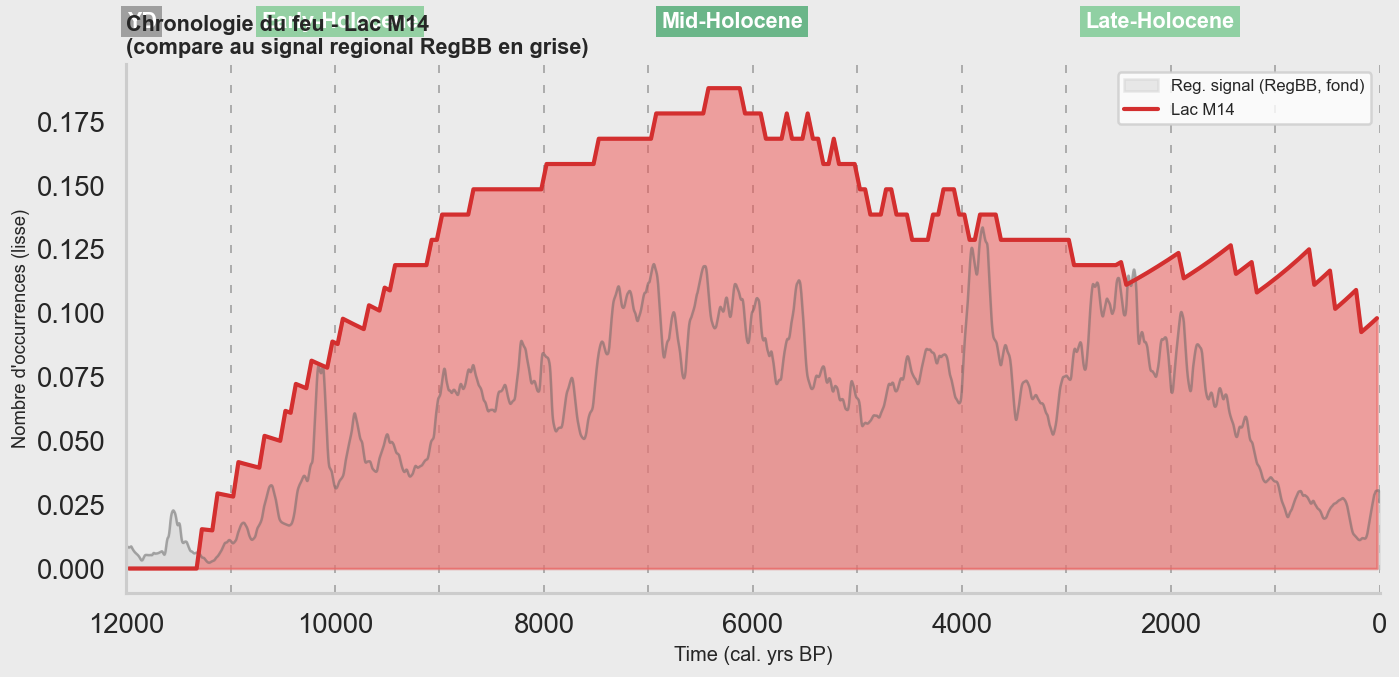

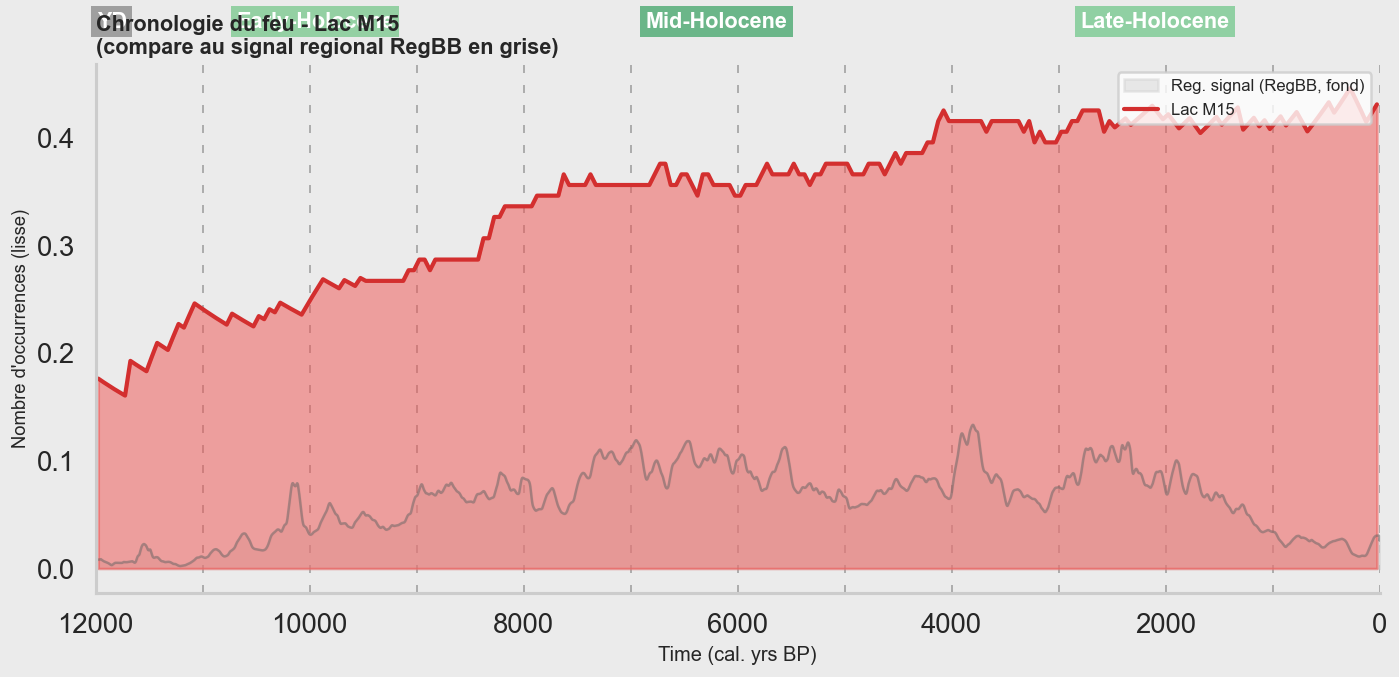

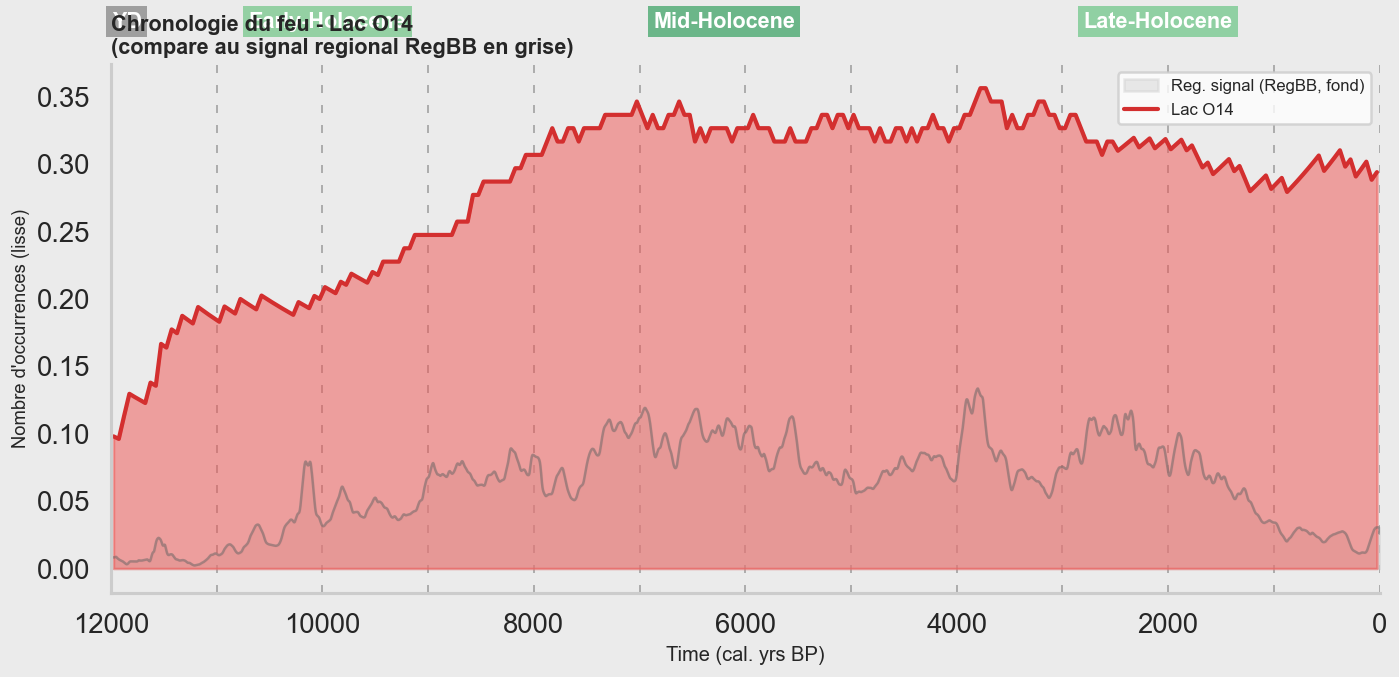

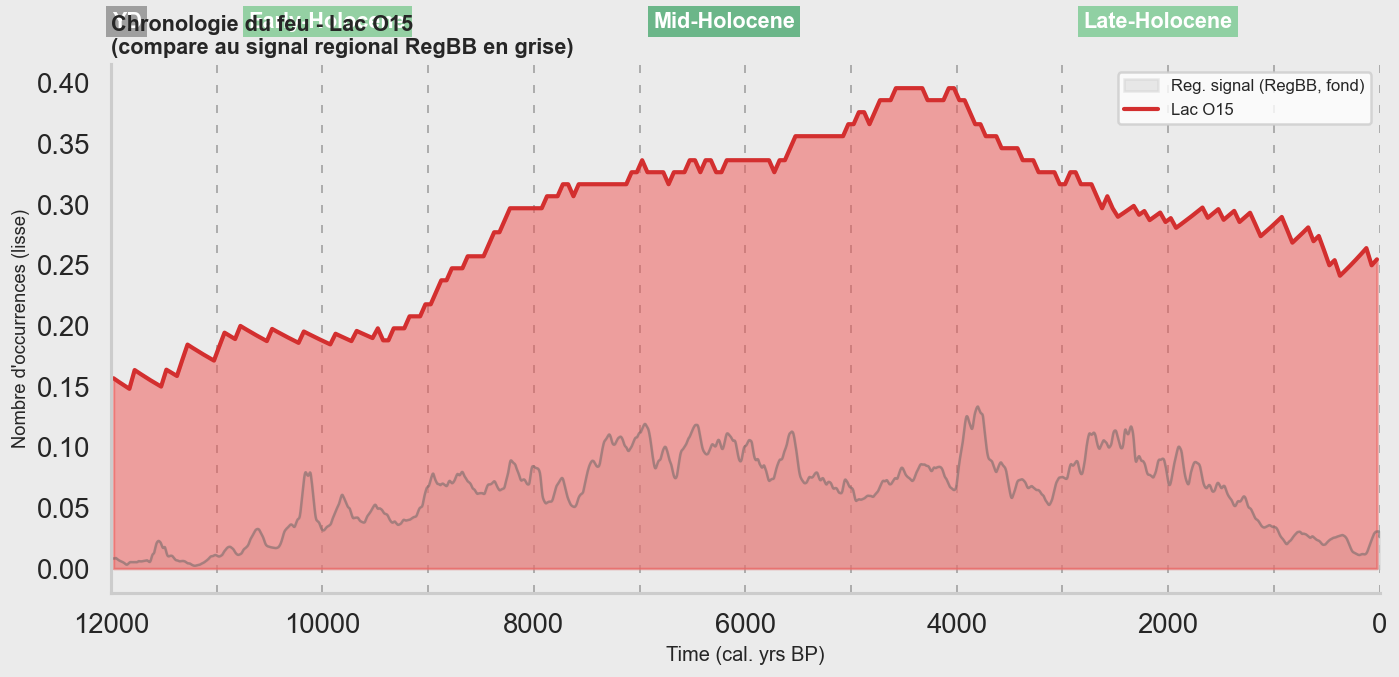

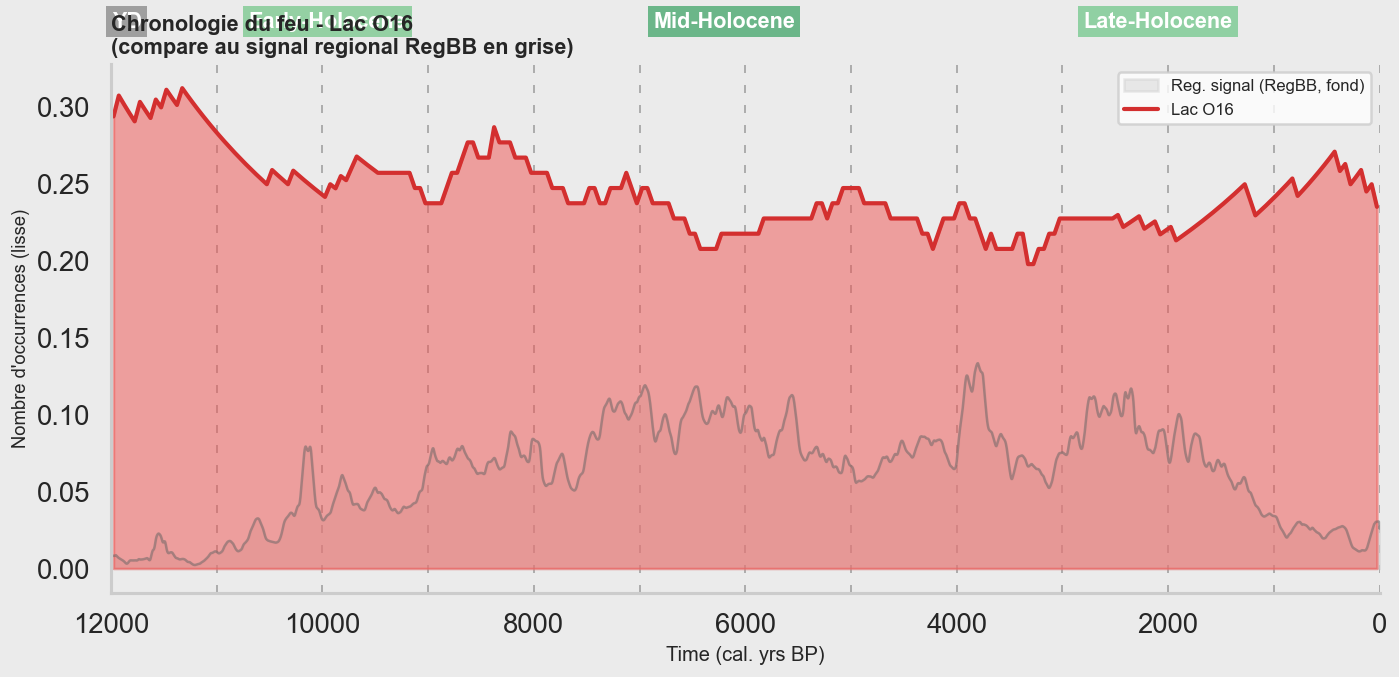

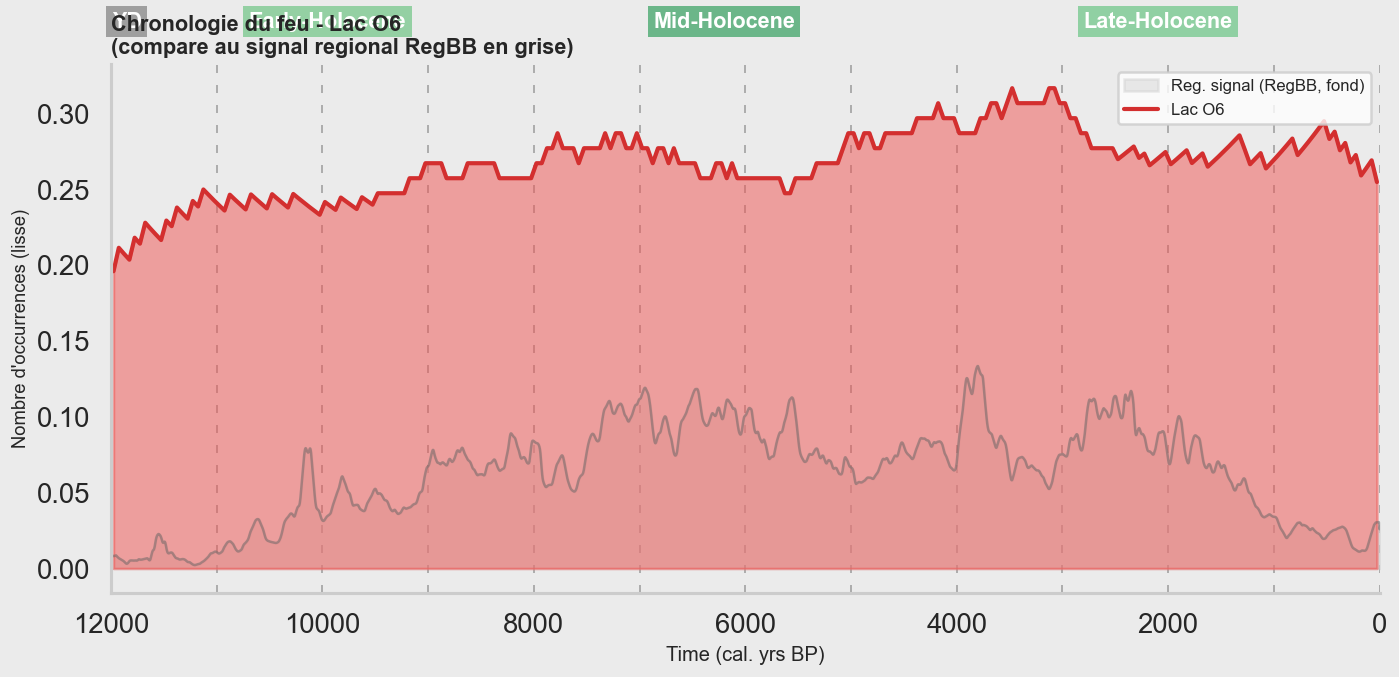


Generation de figures par lac completee.


In [7]:
# Preparation des donnees par lac: lissage et stats par periode
if lake_raw is None:
    print('Lake_fire_frequency_24nov2023.csv non trouve.')
else:
    # Transformer les donnees lake en dataframe long avec ages
    lake = lake_raw.apply(pd.to_numeric, errors='coerce')
    lake = lake.where(lake >= 0)
    lake_long = lake.melt(var_name='Lac', value_name='Age_event').dropna()
    
    # Pour chaque lac, creer une serie temporelle lissee
    lake_series = {}
    for lac_name in sorted(lake_long['Lac'].unique()):
        lac_data = lake_long[lake_long['Lac'] == lac_name].copy()
        
        # Histogram manuellement sur une grille d'ages 0-12000
        ages_grid = np.arange(0, 12001, 50)
        counts, _ = np.histogram(lac_data['Age_event'], bins=np.arange(0, 12050, 50))
        
        # Creer un dataframe compatible avec article_df
        df_lac = pd.DataFrame({
            'Age_calBP': ages_grid[:-1] + 25,  # centre des bins
            'occurrences_count': counts
        })
        
        # Lissage centre (window 101 points comme RegBB_smooth)
        w = 101
        df_lac['occurrences_smooth'] = df_lac['occurrences_count'].rolling(w, center=True, min_periods=1).mean()
        
        lake_series[lac_name] = df_lac
    
    # Generer une figure par lac
    for lac_name in sorted(lake_series.keys()):
        df_lac = lake_series[lac_name]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        fig.patch.set_facecolor('#ebebeb')
        
        # Signal regional grise en arriere-plan (RegBB)
        ax.fill_between(
            article_df['Age_calBP'], 
            0, 
            article_df['RegBB_smooth'], 
            color='#cccccc', alpha=0.4, label='Reg. signal (RegBB, fond)'
        )
        ax.plot(article_df['Age_calBP'], article_df['RegBB_smooth'], color='#666666', lw=1.5, alpha=0.5)
        
        # Signal local du lac (frontal)
        ax.plot(df_lac['Age_calBP'], df_lac['occurrences_smooth'], color='#d32f2f', lw=2.5, label=f'Lac {lac_name}')
        ax.fill_between(
            df_lac['Age_calBP'], 
            0, 
            df_lac['occurrences_smooth'], 
            color='#ef5350', alpha=0.5
        )
        
        ax.set_xlim(0, 12000)
        ax.invert_xaxis()
        ax.set_xlabel('Time (cal. yrs BP)', fontsize=12)
        ax.set_ylabel('Nombre d\'occurrences (lisse)', fontsize=11)
        ax.set_title(f'Chronologie du feu - Lac {lac_name}\n(compare au signal regional RegBB en grise)', 
                     fontsize=13, fontweight='bold', loc='left')
        
        # Grille verticale pour epoques
        for x in np.arange(0, 12001, 1000):
            ax.axvline(x=x, color='0.68', linestyle=(0, (4, 6)), linewidth=1.2, zorder=0)
        
        # Bandeau epoques
        for x0, x1, label, color_bg, color_text in epoch_windows:
            x_center = (x0 + x1) / 2
            ax.text(
                x_center, 1.08, label,
                transform=ax.get_xaxis_transform(),
                ha='center', va='center',
                fontsize=13, fontweight='bold', color=color_text,
                bbox=dict(boxstyle='square,pad=0.25', facecolor=color_bg, edgecolor='none', alpha=0.95)
            )
        
        ax.set_facecolor('#ebebeb')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(False)
        
        plt.tight_layout()
        fig.savefig(figure_dir / f'fig_lac_{lac_name}_chronologie.png', bbox_inches='tight', dpi=150)
        plt.show()
        plt.close(fig)
    
    print("\nGeneration de figures par lac completee.")

### Lectures par lac: interpretation des chronologies locales

#### Lac M15 (le plus actif)
M15 montre ~83 occurrences totales, distribuees sur toute la chronologie avec une densite maximale vers 2000-3000 cal BP.
Comparé au signal régional (grisé), M15 pilote une part importante des variations de RegBB (overlap visible sur la Figure 2 régionale).
Pics marques: 2000-3000, 4000-5000, 7000-8000 cal BP. Activité minimale après 11000 et avant ~1000 cal BP.

#### Lac O15 (intermediaire-actif)
~67 occurrences. Pic majeur visible vers 5000-6000 cal BP (coincidant avec un episode fort du signal régional).
Distribution moins concentrée que M15, avec une contribution plus lissée au regime global.
Chute nette après 11000 cal BP, coherente avec la dynamique régionale.

#### Lac O14 (intermediaire regulier)
~67 occurrences, distribution plutôt uniforme entre 2000 et 10000, sans pic tres marque.
Suggere un apport régulier a la dynamique sans contribution majeure aux exceptionnalités récentes du regime de feu.

#### Lac O16 (intermediaire)
~68 occurrences. Deux phases : forte activité 6000-9000 cal BP, puis declination presque totale après 5000.
Montre une heterogeneite inter-lac importante: certains sites sortent du regime regional a un moment donne.

#### Lac O6 (intermediaire)
~63 occurrences. Profil relativement similaire a O14-O15, sans extrema tres prononces.
Contribution soutenue au signal régional sans episodes de domination locale.

#### Lac M14 (faible contributeur)
Seulement ~29 occurrences. Zeros frequents après 9000-10000 cal BP.
Apport marginal au regime de feu régional; peut refleter des conditions locales moins favorables (etat de conservation, acces).

**Message synthetique par lac:**
M15 + O15 dominent la variabilité observée. Les autres lacs fournissent un apport plus diffus. Cette hierarchie est importante pour evaluer la robustesse du signal régional (si un seul lac dominait, le signal serait moins robuste).

## 6) Analyse detaillee par lac: chronologies locales style article

Cette section decline la Figure 2 (style article) pour chaque lac individuel. Pour chaque site, on montre la chronologie lissee des occurrences de feu sur fond du signal regional (grise), afin de distinguer la variabilite locale du contexte regional.